## Entregable 1
### Mateo Fraguas Abal

**Asignatura:** Técnicas de Lenguaje Natural  
**Curso:** 2026-2027  

## Importaciones

In [ ]:
import json
from pathlib import Path
import pandas as pd
import torch

import re
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC

from transformers import pipeline

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


## Fuente y descripción de los datos

Los datos proceden de Reddit y se descargaron manualmente el 23 de septiembre de 2026. Se conservaron en formato JSON dentro de la carpeta `json/` y contienen publicaciones de los subreddits seleccionados: `nba`, `australia`, `gameofthrones` y `lordoftherings`.

`nba` y `australia` forman el par de temas diferentes, mientras que `gameofthrones` y `lordoftherings` forman el par de temas similares por pertenecer a sagas de fantasía. La celda siguiente muestra la estructura de una respuesta JSON de Reddit. La celda posterior lee todos los archivos disponibles, conserva los campos necesarios y muestra el número de publicaciones obtenido por subreddit.

In [69]:
carpeta_json = Path("json")
archivos_json = sorted(carpeta_json.glob("*.json"))

# Mostrar la primera publicación en JSON con formato legible
archivo_ejemplo = archivos_json[0]

with archivo_ejemplo.open(encoding="utf-8") as archivo:
    contenido_ejemplo = json.load(archivo)

json_formateado = json.dumps(
    contenido_ejemplo,
    indent=1,
)

print("\n".join(json_formateado.splitlines()[:121]))

{
 "kind": "Listing",
 "data": {
  "after": "t3_1wic3un",
  "dist": 100,
  "modhash": "taspy7a98i033b008c1011af1e1726d9ead3e85f59921d68ea",
  "geo_filter": null,
  "children": [
   {
    "kind": "t3",
    "data": {
     "approved_at_utc": null,
     "subreddit": "australia",
     "selftext": "Just another non-political random discussion thread about overpriced goods and services. Supermarket snaps, cafe boards, memes, questions about being ripped off in Australia, lame observations, etc welcome here.",
     "author_fullname": "t2_6l4z3",
     "saved": false,
     "mod_reason_title": null,
     "gilded": 0,
     "clicked": false,
     "title": "[no-politics] Everything overpriced Discussion Thread 23/Sep/2026",
     "link_flair_richtext": [
      {
       "e": "text",
       "t": "no politics"
      }
     ],
     "subreddit_name_prefixed": "r/australia",
     "hidden": false,
     "pwls": 6,
     "link_flair_css_class": "nptag",
     "downs": 0,
     "thumbnail_height": null,
     "top

In [ ]:
publicaciones = []

for ruta_json in archivos_json:
    with ruta_json.open(encoding="utf-8") as archivo:
        contenido = json.load(archivo)

    if isinstance(contenido, dict) and "data" in contenido:
        elementos = contenido["data"].get("children", [])
    elif isinstance(contenido, list):
        elementos = contenido
    else:
        raise ValueError(f"Formato no reconocido en {ruta_json}")

    # Guardamos la información relevante de cada publicación en un diccionario
    for elemento in elementos:
        publicacion = elemento.get("data", elemento)
        titulo = publicacion.get("title", "")
        cuerpo = publicacion.get("selftext", publicacion.get("texto", ""))
        texto = f"{titulo}\n{cuerpo}".strip()

        publicaciones.append({
            "texto": texto,
            "fecha": publicacion.get("created_utc", publicacion.get("fecha")),
            "subreddit": publicacion.get("subreddit", ruta_json.stem),
            "autor": publicacion.get("author", publicacion.get("autor"))
        })

# Guardamos los datos en un DataFrame de pandas y eliminamos las publicaciones sin texto
datos = pd.DataFrame(publicaciones)
datos = datos.dropna(subset=["texto"]).copy()

# Convertimos la columna "fecha" a tipo datetime
datos["fecha"] = pd.to_datetime(datos["fecha"], unit="s", errors="coerce")

# Equilibramos las clases usando el número mínimo de publicaciones disponible
recuento_original = datos["subreddit"].value_counts().sort_index()
n_publicaciones_equilibrado = recuento_original.min()
datos = (
    datos.sort_values(["subreddit", "fecha"])
    .groupby("subreddit", group_keys=False)
    .tail(n_publicaciones_equilibrado) # Tomamos las últimas n publicaciones
    .sort_values("fecha")
    .reset_index(drop=True)
)

# Guardamos los datos equilibrados en un archivo CSV
datos.to_csv("datos.csv", index=False, encoding="utf-8")

fecha_descarga = "2026-09-23"
publicaciones_por_subreddit = datos["subreddit"].value_counts().sort_index()
publicaciones_descartadas = len(publicaciones) - len(datos)

print(f"Fecha de descarga registrada: {fecha_descarga}")
print(f"Archivos JSON leídos: {len(archivos_json)}")
print(f"Publicaciones cargadas antes del equilibrio: {len(publicaciones)}")
print(f"Publicaciones descartadas para equilibrar: {publicaciones_descartadas}")
print(f"Publicaciones utilizadas: {len(datos)}")
print(publicaciones_por_subreddit)
print(datos.head())

Fecha de descarga registrada: 2026-09-23
Archivos JSON leídos: 36
Publicaciones cargadas antes del equilibrio: 3416
Publicaciones descartadas para equilibrar: 156
Publicaciones utilizadas: 3260
subreddit
australia         815
gameofthrones     815
lordoftherings    815
nba               815
Name: count, dtype: int64
                                               texto               fecha  \
0  Every time I look at a map of Eriador, I see t... 2026-07-08 09:35:26   
1  Salam Alaykum, my woman gave me a Lord Of The ... 2026-07-08 15:17:18   
2  Did Hobbits ever live in eastern Middle Earth ... 2026-07-08 19:56:04   
3                                      Siege of Dale 2026-07-08 22:32:09   
4  Oura Ring/LOTR Skins for Ring\nI’m looking to ... 2026-07-08 23:51:12   

        subreddit            autor  
0  lordoftherings   Erathor_Noname  
1  lordoftherings   Spirit_Caller_  
2  lordoftherings  Tidewatcher7819  
3  lordoftherings  PopeJohnPaul961  
4  lordoftherings         kleoless  


## Entrenamiento

### Preparación de los datos

Las publicaciones se ordenan por fecha dentro de cada subreddit y se reserva el último 30 % de cada uno como conjunto de test. El conjunto de test no se utiliza para ajustar el vectorizador ni los clasificadores. 

In [71]:
# Ordenar cronológicamente dentro de cada subreddit

datos = datos.sort_values(["subreddit", "fecha"]).reset_index(drop=True)

# Reservar el último 30 % de cada subreddit para test
particiones_train = []
particiones_test = []

for subreddit, grupo in datos.groupby("subreddit", sort=True):
    n_test_subreddit = int(0.3 * len(grupo))
    particiones_train.append(grupo.iloc[:-n_test_subreddit])
    particiones_test.append(grupo.iloc[-n_test_subreddit:])

train_data = pd.concat(particiones_train).sort_values("fecha").reset_index(drop=True)
test_data = pd.concat(particiones_test).sort_values("fecha").reset_index(drop=True)

print(f"Conjunto de entrenamiento: {len(train_data)} publicaciones")
print(f"Conjunto de prueba: {len(test_data)} publicaciones")

for subreddit in sorted(datos["subreddit"].unique()):
    train_subreddit = train_data[train_data["subreddit"] == subreddit]
    test_subreddit = test_data[test_data["subreddit"] == subreddit]
    print(
        f"{subreddit}: entrenamiento={len(train_subreddit)},\n\ttest={len(test_subreddit)}, \n\túltima fecha de entrenamiento={train_subreddit['fecha'].max()}, \n\tprimera fecha de test={test_subreddit['fecha'].min()}"
    )

Conjunto de entrenamiento: 2284 publicaciones
Conjunto de prueba: 976 publicaciones
australia: entrenamiento=571,
	test=244, 
	última fecha de entrenamiento=2026-09-10 02:42:54, 
	primera fecha de test=2026-09-10 03:58:39
gameofthrones: entrenamiento=571,
	test=244, 
	última fecha de entrenamiento=2026-09-14 15:09:52, 
	primera fecha de test=2026-09-14 15:50:06
lordoftherings: entrenamiento=571,
	test=244, 
	última fecha de entrenamiento=2026-09-04 08:37:58, 
	primera fecha de test=2026-09-04 09:19:24
nba: entrenamiento=571,
	test=244, 
	última fecha de entrenamiento=2026-09-28 23:03:02, 
	primera fecha de test=2026-09-29 00:30:16


### Limpieza

### Preprocesamiento y representación TF-IDF

Se limpian las URLs, símbolos y espacios innecesarios. El `TfidfVectorizer` se ajusta únicamente con el entrenamiento y después transforma el test con el mismo vocabulario, evitando incorporar información del test durante el entrenamiento.

In [72]:


def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Preprocesamiento del texto
texto_train = train_data["texto"].fillna("").map(limpiar_texto)
texto_test = test_data["texto"].fillna("").map(limpiar_texto)

# El vectorizador se ajusta únicamente con entrenamiento
vectorizador = TfidfVectorizer(
    lowercase=False,
    min_df=2,
    max_df=0.95,
    stop_words="english"
)

X_train = vectorizador.fit_transform(texto_train)
X_test = vectorizador.transform(texto_test)

# un valor distinto para cada subreddit
etiquetas = {subreddit: indice for indice, subreddit in enumerate(
    sorted(train_data["subreddit"].unique())
)}

y = train_data["subreddit"].map(etiquetas).to_numpy()
y_test = test_data["subreddit"].map(etiquetas).to_numpy()

print(f"Matriz de entrenamiento: {X_train.shape}")
print(f"Publicaciones: {X_train.shape[0]}")
print(f"Número de palabras: {X_train.shape[1]}")
print(f"Etiquetas: {etiquetas}")

Matriz de entrenamiento: (2284, 7638)
Publicaciones: 2284
Número de palabras: 7638
Etiquetas: {'australia': 0, 'gameofthrones': 1, 'lordoftherings': 2, 'nba': 3}


## SVM

## Clasificación SVM

Se comparan dos pares de subreddits: `nba` frente a `australia` como par diferente, y `lordoftherings` frente a `gameofthrones` como par similar. Para cada par se prueban varios valores de `C` y los kernels `linear` y `rbf`. La métrica principal es `accuracy` y también se muestran las matrices de confusión.

In [73]:

pares = [
    ("nba", "australia"),
    ("lordoftherings", "gameofthrones")
]

valores_C = [0.1, 1, 10, 100]
kernels = ["linear", "rbf"]

resultados_svm = []
modelos_svm = {}

subreddit_train = train_data["subreddit"].to_numpy()
subreddit_test = test_data["subreddit"].to_numpy()

for par in pares:
    mascara_train = pd.Series(subreddit_train).isin(par).to_numpy()
    mascara_test = pd.Series(subreddit_test).isin(par).to_numpy()

    X_train_par = X_train[mascara_train]
    X_test_par = X_test[mascara_test]
    y_train_par = subreddit_train[mascara_train]
    y_test_par = subreddit_test[mascara_test]

    for kernel in kernels:
        for C in valores_C:
            clasificador = SVC(C=C, kernel=kernel)
            clasificador.fit(X_train_par, y_train_par)

            predicciones = clasificador.predict(X_test_par)
            exactitud = (predicciones == y_test_par).mean()

            clave = f"{par[0]}_vs_{par[1]}_{kernel}_C{C}"
            modelos_svm[clave] = clasificador

            resultados_svm.append({
                "par": f"{par[0]} vs {par[1]}",
                "kernel": kernel,
                "C": C,
                "entrenamiento": len(y_train_par),
                "test": len(y_test_par),
                "exactitud": exactitud
            })

resultados_svm = pd.DataFrame(resultados_svm)
resultados_svm = resultados_svm.sort_values(
    by=["par", "exactitud"],
    ascending=[True, False]
).reset_index(drop=True)

resultados_svm.to_csv("resultados_svm.csv", index=False, encoding="utf-8")
display(resultados_svm)

,par,kernel,C,entrenamiento,test,exactitud
0,lordoftherings vs gameofthrones,rbf,1.0,1142,488,0.911885
1,lordoftherings vs gameofthrones,linear,1.0,1142,488,0.909836
2,lordoftherings vs gameofthrones,rbf,10.0,1142,488,0.905738
3,lordoftherings vs gameofthrones,rbf,100.0,1142,488,0.905738
4,lordoftherings vs gameofthrones,linear,0.1,1142,488,0.903689
5,lordoftherings vs gameofthrones,linear,10.0,1142,488,0.895492
6,lordoftherings vs gameofthrones,linear,100.0,1142,488,0.877049
7,lordoftherings vs gameofthrones,rbf,0.1,1142,488,0.844262
8,nba vs australia,rbf,10.0,1142,488,0.954918
9,nba vs australia,rbf,100.0,1142,488,0.954918


### Evaluación de los clasificadores

Para cada configuración se calcula `accuracy` y se construye una matriz de confusión con el orden de clases indicado en cada par. La tabla y las matrices permiten comparar tanto el rendimiento global como los errores entre clases.

La tabla siguiente muestra la exactitud de cada configuración, la comparación por kernel y valor de `C`, la mejor configuración de cada par y sus matrices de confusión.

In [74]:
evaluaciones = []
matrices_confusion = {}

for par in pares:
    mascara_test = pd.Series(subreddit_test).isin(par).to_numpy()
    X_test_par = X_test[mascara_test]
    y_test_par = subreddit_test[mascara_test]

    for kernel in kernels:
        for C in valores_C:
            clave = f"{par[0]}_vs_{par[1]}_{kernel}_C{C}"
            clasificador = modelos_svm[clave]

            predicciones = clasificador.predict(X_test_par)
            accuracy = (predicciones == y_test_par).mean()

            matriz = confusion_matrix(
                y_test_par,
                predicciones,
                labels=list(par)
            )

            evaluaciones.append({
                "par": f"{par[0]} vs {par[1]}",
                "kernel": kernel,
                "C": C,
                "accuracy": accuracy
            })

            matrices_confusion[clave] = pd.DataFrame(
                matriz,
                index=[f"Real: {etiqueta}" for etiqueta in par],
                columns=[f"Predicha: {etiqueta}" for etiqueta in par]
            )

evaluaciones = pd.DataFrame(evaluaciones)

display(
    evaluaciones.sort_values(
        ["par", "accuracy"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

display(
    evaluaciones.pivot_table(
        index=["par", "kernel"],
        columns="C",
        values="accuracy"
    )
)

mejores = evaluaciones.loc[
    evaluaciones.groupby("par")["accuracy"].idxmax()
].reset_index(drop=True)
display(mejores)

for clave, matriz in matrices_confusion.items():
    print(f"\n{clave}")
    display(matriz)

for _, fila in mejores.iterrows():
    print(
        f"- {fila['par']}: mejor configuración = "
        f"{fila['kernel']} con C={fila['C']}, "
        f"accuracy={fila['accuracy']:.3f}"
    )

accuracy_similares = mejores.loc[
    mejores["par"] == "lordoftherings vs gameofthrones",
    "accuracy"
].iloc[0]

accuracy_diferentes = mejores.loc[
    mejores["par"] == "nba vs australia",
    "accuracy"
].iloc[0]

print(
    f"\nEl par de cuentas similares obtiene una accuracy de "
    f"{accuracy_similares:.3f}, mientras que el par de cuentas diferentes "
    f"obtiene {accuracy_diferentes:.3f}."
)

,par,kernel,C,accuracy
0,lordoftherings vs gameofthrones,rbf,1.0,0.911885
1,lordoftherings vs gameofthrones,linear,1.0,0.909836
2,lordoftherings vs gameofthrones,rbf,10.0,0.905738
3,lordoftherings vs gameofthrones,rbf,100.0,0.905738
4,lordoftherings vs gameofthrones,linear,0.1,0.903689
5,lordoftherings vs gameofthrones,linear,10.0,0.895492
6,lordoftherings vs gameofthrones,linear,100.0,0.877049
7,lordoftherings vs gameofthrones,rbf,0.1,0.844262
8,nba vs australia,rbf,10.0,0.954918
9,nba vs australia,rbf,100.0,0.954918


C                                          0.1       1.0       10.0      100.0
par                             kernel                                        
lordoftherings vs gameofthrones linear  0.903689  0.909836  0.895492  0.877049
                                rbf     0.844262  0.911885  0.905738  0.905738
nba vs australia                linear  0.870902  0.940574  0.938525  0.932377
                                rbf     0.721311  0.950820  0.954918  0.954918

,par,kernel,C,accuracy
0,lordoftherings vs gameofthrones,rbf,1.0,0.911885
1,nba vs australia,rbf,10.0,0.954918



nba_vs_australia_linear_C0.1


,Predicha: nba,Predicha: australia
Real: nba,181,63
Real: australia,0,244


...


lordoftherings_vs_gameofthrones_rbf_C10


,Predicha: lordoftherings,Predicha: gameofthrones
Real: lordoftherings,213,31
Real: gameofthrones,15,229



lordoftherings_vs_gameofthrones_rbf_C100


,Predicha: lordoftherings,Predicha: gameofthrones
Real: lordoftherings,213,31
Real: gameofthrones,15,229


- lordoftherings vs gameofthrones: mejor configuración = rbf con C=1.0, accuracy=0.912
- nba vs australia: mejor configuración = rbf con C=10.0, accuracy=0.955

El par de cuentas similares obtiene una accuracy de 0.912, mientras que el par de cuentas diferentes obtiene 0.955.


Conclusiones:
- `lordoftherings` vs `gameofthrones`: mejor configuración = `rbf` con `C=1.0`, `accuracy=0.912`.
- `nba` vs `australia`: mejor configuración = `rbf` con `C=10.0`, `accuracy=0.955`.

El par de cuentas similares obtiene una accuracy de 0.912, mientras que el par de cuentas diferentes obtiene 0.955. Por tanto, distinguir cuentas de temas similares sigue siendo más difícil. El aumento de datos y el equilibrio entre clases han cambiado ligeramente las configuraciones y mejorado las accuracies respecto al experimento anterior.
Los errores pueden deberse a publicaciones ambiguas, textos muy cortos, vocabulario compartido entre subreddits y la ausencia de información semántica más profunda en la representación TF-IDF.

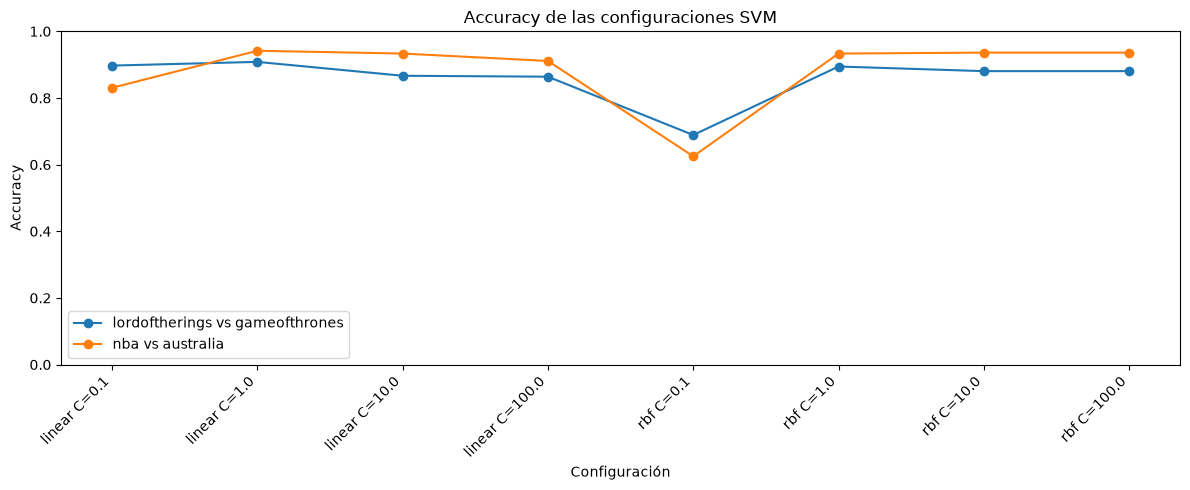

In [61]:
plt.figure(figsize=(12, 5))
for par, grupo in evaluaciones.groupby("par"):
    etiquetas_grafico = grupo["kernel"] + " C=" + grupo["C"].astype(str)
    plt.plot(etiquetas_grafico, grupo["accuracy"], marker="o", label=par)

plt.xlabel("Configuración")
plt.ylabel("Accuracy")
plt.title("Accuracy de las configuraciones SVM")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Análisis de sentimiento con VADER

VADER asigna puntuaciones `neg`, `neu`, `pos` y `compound` a cada publicación. Se resumen las puntuaciones por subreddit y se interpretan con cautela porque el modelo está diseñado principalmente para textos breves en inglés.

La tabla muestra las estadísticas agregadas por subreddit. El valor más positivo y el más negativo se indican a partir de la media de `compound`. VADER puede tener dificultades con ironía, contexto especializado o publicaciones muy breves.

In [75]:

analizador_sentimiento = SentimentIntensityAnalyzer()

# Analizar todas las publicaciones
puntuaciones = datos["texto"].fillna("").apply(
    analizador_sentimiento.polarity_scores
).apply(pd.Series)

datos_sentimiento = pd.concat(
    [datos.reset_index(drop=True), puntuaciones.reset_index(drop=True)],
    axis=1
)

# Clasificación estándar de VADER: negativa, neutral o positiva
datos_sentimiento["categoria_sentimiento"] = pd.cut(
    datos_sentimiento["compound"],
    bins=[-float("inf"), -0.05, 0.05, float("inf")],
    labels=["negativa", "neutral", "positiva"],
    include_lowest=True
)

# Estadísticas agregadas por subreddit
estadisticas_sentimiento = datos_sentimiento.groupby("subreddit").agg(
    publicaciones=("texto", "count"),
    media_compound=("compound", "mean"),
    mediana_compound=("compound", "median"),
    desviacion_compound=("compound", "std"),
    media_positiva=("pos", "mean"),
    media_neutral=("neu", "mean"),
    media_negativa=("neg", "mean"),
    publicaciones_positivas=("categoria_sentimiento", lambda valores: (valores == "positiva").sum()),
    publicaciones_neutrales=("categoria_sentimiento", lambda valores: (valores == "neutral").sum()),
    publicaciones_negativas=("categoria_sentimiento", lambda valores: (valores == "negativa").sum())
).sort_values("media_compound", ascending=False)

display(estadisticas_sentimiento.round(3))

# Comparación de sentimiento
subreddit_mas_positivo = estadisticas_sentimiento["media_compound"].idxmax()
subreddit_mas_negativo = estadisticas_sentimiento["media_compound"].idxmin()

print(f"Cuenta con sentimiento medio más positivo: {subreddit_mas_positivo}")
print(f"Cuenta con sentimiento medio más negativo: {subreddit_mas_negativo}")

# Guardar resultados
datos_sentimiento.to_csv(
    "datos_sentimiento.csv",
    index=False,
    encoding="utf-8"
)
estadisticas_sentimiento.to_csv(
    "estadisticas_sentimiento.csv",
    encoding="utf-8"
)

,publicaciones,media_compound,mediana_compound,desviacion_compound,media_positiva,media_neutral,media_negativa,publicaciones_positivas,publicaciones_neutrales,publicaciones_negativas
subreddit,,,,,,,,,,
nba,815,0.297,0.422,0.591,0.102,0.849,0.049,498,122,195
lordoftherings,815,0.213,0.000,0.489,0.108,0.852,0.040,382,299,134
gameofthrones,815,0.042,0.000,0.677,0.106,0.803,0.091,374,113,328
australia,815,-0.030,0.000,0.542,0.078,0.814,0.107,291,175,349


Cuenta con sentimiento medio más positivo: nba
Cuenta con sentimiento medio más negativo: australia


Conclusiones:
La puntuación compound resume el sentimiento general de cada publicación: valores positivos indican un tono más positivo y valores negativos un tono más negativo.
Según la media compound, nba presenta el tono más positivo, mientras que australia presenta el tono más negativo.
Las diferencias deben interpretarse con cautela, ya que VADER es un modelo basado en reglas y puede tener dificultades con ironía, contexto especializado o publicaciones muy breves.

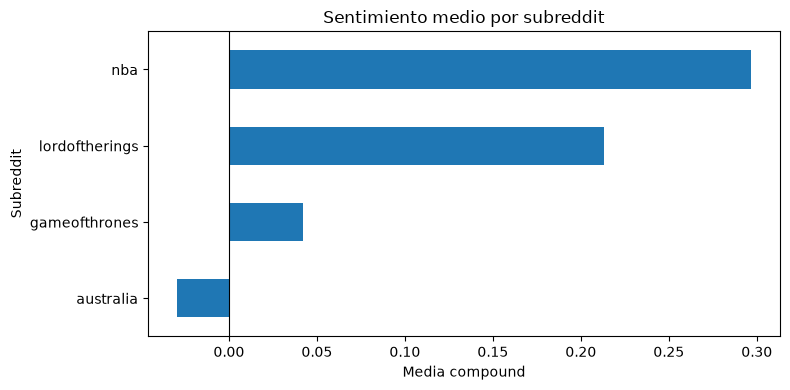

In [76]:
estadisticas_sentimiento["media_compound"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Sentimiento medio por subreddit",
    xlabel="Media compound",
    ylabel="Subreddit"
)
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Comparación opcional con BERT

El modelo multilingüe de Hugging Face produce una valoración de 1 a 5 estrellas. Se normaliza a la escala `[-1, 1]` para compararla con el valor `compound` de VADER. También se prueban textos en castellano y gallego.

Se muestran la comparación media por subreddit, la correlación entre VADER y BERT, la diferencia media absoluta y las publicaciones con mayor discrepancia. Para el texto en castellano se conserva la puntuación de BERT y su versión normalizada.

In [ ]:
# Cargar el modelo multilingüe desde Hugging Face
clasificador_bert = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0 if torch.cuda.is_available() else -1
)

# Aplicar BERT a las mismas publicaciones analizadas con VADER
resultados_bert = clasificador_bert(
    datos["texto"].fillna("").tolist(),
    truncation=True,
    batch_size=16
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3981.13it/s]


KeyboardInterrupt: 

In [ ]:

# Convertir "1 star", ..., "5 stars" a valores numéricos
puntuaciones_bert = pd.Series(
    [int(resultado["label"].split()[0]) for resultado in resultados_bert],
    name="bert_estrellas"
)

# Normalización de 1-5 a una escala comparable con VADER: [-1, 1]
puntuaciones_bert_normalizadas = (
    (puntuaciones_bert - 3) / 2
).rename("bert_normalizado")

datos_comparacion = pd.concat(
    [
        datos_sentimiento.reset_index(drop=True),
        puntuaciones_bert.reset_index(drop=True),
        puntuaciones_bert_normalizadas.reset_index(drop=True)
    ],
    axis=1
)

# Comparación de estadísticas
comparacion = datos_comparacion.groupby("subreddit").agg(
    publicaciones=("texto", "count"),
    vader_compound=("compound", "mean"),
    bert_normalizado=("bert_normalizado", "mean"),
    bert_estrellas=("bert_estrellas", "mean"))

display(comparacion.round(3))

print(datos_comparacion[["compound", "bert_normalizado"]]\
    .corr()\
    .round(3))

# Diferencia entre las puntuaciones de ambos métodos
datos_comparacion["diferencia"] = (
    datos_comparacion["bert_normalizado"]
    - datos_comparacion["compound"])

print(datos_comparacion["diferencia"].abs().mean().round(3))

# Ejemplos con mayor discrepancia
display(datos_comparacion[["texto", "compound", "bert_estrellas", "bert_normalizado", "diferencia"]]\
    .sort_values("diferencia", key=abs, ascending=False)\
    .head(10))

texto_castellano = ("Me ha encantado esta película, la historia es emocionante y los personajes están muy bien construidos.")

resultado_castellano = clasificador_bert(
    texto_castellano,
    truncation=True
)[0]

puntuacion_castellano = int(resultado_castellano["label"].split()[0])
normalizada_castellano = (puntuacion_castellano - 3) / 2

print(f"Texto: {texto_castellano}")
print(f"Puntuación BERT: {puntuacion_castellano}/5")
print(f"Puntuación normalizada: {normalizada_castellano:.2f}")

,publicaciones,vader_compound,bert_normalizado,bert_estrellas
subreddit,,,,
australia,600,-0.017,-0.374,2.252
gameofthrones,600,0.024,0.029,3.058
lordoftherings,600,0.203,0.338,3.675
nba,600,0.293,-0.038,2.925


                  compound  bert_normalizado
compound             1.000             0.256
bert_normalizado     0.256             1.000
0.698


,texto,compound,bert_estrellas,bert_normalizado,diferencia
2148,Empire State of Hive Mind: The Universal Overr...,0.9995,1,-1.0,-1.9995
1314,Is Bilbo's Sacrifice Salvation? A Theological ...,0.9987,1,-1.0,-1.9987
1126,The Red Wedding\nI just watched episode 9 of s...,-0.9963,5,1.0,1.9963
1969,[Arthur] “I think that there’s a whole longer ...,0.9960,1,-1.0,-1.9960
2385,The floor raiser/ceiling raiser thing is illog...,0.9959,1,-1.0,-1.9959
1071,Cersei’s hatred of Tyrion literally overshadow...,-0.9869,5,1.0,1.9869
1888,The last time a Pistons center took the qualif...,0.9841,1,-1.0,-1.9841
2000,[Charania] Clippers owner Steve Ballmer is com...,0.9836,1,-1.0,-1.9836
64,"Why Solar Sharer has become the solar shocker,...",0.9790,1,-1.0,-1.9790
1944,[Stein] Sources briefed on the situation tell ...,0.9767,1,-1.0,-1.9767


Texto: Me ha encantado esta película, la historia es emocionante y los personajes están muy bien construidos.
Puntuación BERT: 5/5
Puntuación normalizada: 1.00


Interpretación: VADER utiliza reglas léxicas y está especialmente orientado a textos breves en inglés, por lo que puede verse afectado por ironías, contexto y vocabulario especializado. BERT analiza el contexto mediante representaciones lingüísticas multilingües y produce una valoración ordinal de 1 a 5 estrellas. Por ello, ambos métodos pueden asignar puntuaciones diferentes, especialmente en textos cortos o ambiguos.
El modelo BERT funciona con el texto en castellano porque fue entrenado como modelo multilingüe. No obstante, su precisión puede variar según el idioma, el contexto y el tipo de texto.

In [66]:
# Evaluación del modelo en castellano y gallego
textos_prueba = {
    "castellano": [
        "Me ha encantado esta película, la historia es emocionante y los personajes están muy bien construidos.",
        "La película es aburrida, la historia no tiene sentido y los personajes están mal desarrollados."
    ],
    "gallego": [
        "Encantoume esta película, a historia é emocionante e os personaxes están moi ben construídos.",
        "A película é aburrida, a historia non ten sentido e os personaxes están mal desenvolvidos."
    ]
}

resultados_idiomas = []

for idioma, textos in textos_prueba.items():
    predicciones = clasificador_bert(textos, truncation=True)

    for texto_actual, prediccion in zip(textos, predicciones):
        estrellas = int(prediccion["label"].split()[0])
        resultados_idiomas.append({
            "idioma": idioma,
            "texto": texto_actual,
            "valoracion": estrellas,
            "confianza": prediccion["score"]
        })

resultados_idiomas = pd.DataFrame(resultados_idiomas)
display(resultados_idiomas.round(3))


,idioma,texto,valoracion,confianza
0,castellano,"Me ha encantado esta película, la historia es ...",5,0.812
1,castellano,"La película es aburrida, la historia no tiene ...",1,0.588
2,gallego,"Encantoume esta película, a historia é emocion...",5,0.856
3,gallego,"A película é aburrida, a historia non ten sent...",1,0.621


El modelo puede procesar castellano y gallego porque utiliza un modelo multilingüe, sin embargo, el gallego puede tener menor precisión. En este caso

## Conclusiones finales

- Se reunieron las publicaciones de los cuatro subreddits a partir de los archivos JSON locales y se documentaron la fuente, la fecha de descarga y el número de publicaciones por subreddit.
- La división temporal reserva el último 30 % de las publicaciones para test, evitando utilizar esos datos durante el entrenamiento.
- La representación TF-IDF y los clasificadores SVM permiten comparar la dificultad de distinguir el par de temas diferentes con la del par de temas similares. La configuración con mayor `accuracy` se identifica en la tabla de resultados y en las matrices de confusión.
- El análisis VADER resume el tono de las publicaciones mediante la puntuación `compound`, pero sus resultados deben interpretarse con cautela en textos breves, irónicos o especializados.
- El modelo BERT multilingüe ofrece una segunda valoración y permite estudiar las diferencias entre inglés, castellano y gallego. Las discrepancias entre modelos no implican necesariamente que uno de ellos sea siempre correcto.
- Como limitaciones, los resultados dependen de las publicaciones disponibles, del equilibrio entre subreddits y de la representación TF-IDF; además, la clasificación de sentimiento puede verse afectada por el idioma y el contexto.

En las pruebas de idioma, BERT asigna valoraciones a textos positivos y negativos tanto en castellano como en gallego. La confianza de cada predicción debe interpretarse como una estimación del modelo, no como una garantía de corrección.